# Healthcare Readmission Analysis

End-to-end analysis of 30-day hospital readmission using data cleaning, exploratory analysis, feature engineering, machine learning, calibration, and SHAP model interpretation.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("C:/Users/Yohanes E/Desktop/healthcare-intelligence/data/raw/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.shape

(101766, 50)

In [ ]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [ ]:
df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

In [ ]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

max_glu_serum    96420
A1Cresult        84748
dtype: int64

In [ ]:
(df == "?").sum().sort_values(ascending=False)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
admission_type_id               0
patient_nbr                     0
encounter_id                    0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [ ]:
df["readmitted"].value_counts(normalize=True) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

In [ ]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [ ]:
df.nunique().sort_values()

citoglipton                      1
examide                          1
acetohexamide                    2
glipizide-metformin              2
tolbutamide                      2
troglitazone                     2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
metformin-pioglitazone           2
change                           2
diabetesMed                      2
gender                           3
tolazamide                       3
readmitted                       3
max_glu_serum                    3
A1Cresult                        3
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
miglitol                         4
glimepiride                      4
metformin                        4
nateglinide                      4
repaglinide                      4
chlorpropamide                   4
glipizide                        4
glyburide                        4
insulin                          4
glyburide-metformin 

In [ ]:
df["encounter_id"].duplicated().sum()

np.int64(0)

In [ ]:
df["patient_nbr"].nunique()

71518

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [ ]:
df.nunique().sort_values()

citoglipton                      1
examide                          1
acetohexamide                    2
glipizide-metformin              2
tolbutamide                      2
troglitazone                     2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
metformin-pioglitazone           2
change                           2
diabetesMed                      2
gender                           3
tolazamide                       3
readmitted                       3
max_glu_serum                    3
A1Cresult                        3
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
miglitol                         4
glimepiride                      4
metformin                        4
nateglinide                      4
repaglinide                      4
chlorpropamide                   4
glipizide                        4
glyburide                        4
insulin                          4
glyburide-metformin 

In [ ]:
df["encounter_id"].duplicated().sum()

np.int64(0)

In [ ]:
print("AGE VALUES:")
print(df["age"].value_counts().sort_index())

print("\n\nGENDER VALUES:")
print(df["gender"].value_counts())

print("\n\nRACE VALUES:")
print(df["race"].value_counts(dropna=False))

print("\n\nWEIGHT VALUES:")
print(df["weight"].value_counts(dropna=False))

print("\n\nMAX GLUCOSE VALUES:")
print(df["max_glu_serum"].value_counts(dropna=False))

print("\n\nA1C VALUES:")
print(df["A1Cresult"].value_counts(dropna=False))

print("\n\nDIABETES MEDICATION VALUES:")
print(df["diabetesMed"].value_counts())

print("\n\nCHANGE VALUES:")
print(df["change"].value_counts())


AGE VALUES:
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


GENDER VALUES:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


RACE VALUES:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


WEIGHT VALUES:
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64


MAX GLUCOSE VALUES:
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64


A1C VALUES:
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype:

In [ ]:
question_mark_counts = (df == "?").sum().sort_values(ascending=False) 
question_mark_counts[question_mark_counts > 0] 


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [ ]:
print("Total '?' values:", (df == "?").sum().sum())

Total '?' values: 192849


In [ ]:
# =================================================
# STEP 1: CREATE WORKING DATASET
# =================================================

df_clean = df.copy() 
print("Original shape:", df.shape) 
print("Working shape:", df_clean.shape) 


Original shape: (101766, 50)
Working shape: (101766, 50)


In [ ]:
df_clean = df_clean.replace("?", pd.NA)

In [ ]:
print(df_clean.isna().sum().sort_values(ascending=False).head(15))

weight                 98569
max_glu_serum          96420
A1Cresult              84748
medical_specialty      49949
payer_code             40256
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
patient_nbr                0
time_in_hospital           0
admission_source_id        0
num_lab_procedures         0
encounter_id               0
admission_type_id          0
dtype: int64


In [ ]:
print("Missing values after standardization:")
print(df_clean.isna().sum().sort_values(ascending=False).head(15))



Missing values after standardization:
weight                 98569
max_glu_serum          96420
A1Cresult              84748
medical_specialty      49949
payer_code             40256
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
patient_nbr                0
time_in_hospital           0
admission_source_id        0
num_lab_procedures         0
encounter_id               0
admission_type_id          0
dtype: int64


In [ ]:
print("\nRemaining '?' values:")
print((df_clean == "?").sum().sum())



Remaining '?' values:
0


In [ ]:
df_clean = df_clean.drop(columns=["weight"])

In [ ]:
print(df_clean.shape)

(101766, 49)


In [ ]:
print(df_clean["medical_specialty"].value_counts(dropna=False).head(20))

medical_specialty
NaN                                  49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Name: count, dtype: int64


In [ ]:
print(df_clean["payer_code"].value_counts(dropna=False))

payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64


In [ ]:
print("DIAG_1:")
print(df_clean["diag_1"].value_counts(dropna=False).head(20))

print("\nDIAG_2:")
print(df_clean["diag_2"].value_counts(dropna=False).head(20))

print("\nDIAG_3:")
print(df_clean["diag_3"].value_counts(dropna=False).head(20))




DIAG_1:
diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

DIAG_2:
diag_2
276       6752
428       6662
250       6071
427       5036
401       3736
496       3305
599       3288
403       2823
414       2650
411       2566
250.02    2074
707       1999
585       1871
584       1649
491       1545
250.01    1523
285       1520
780       1491
425       1434
682       1433
Name: count, dtype: int64

DIAG_3:
diag_3
250       11555
401        8289
276        5175
428        4577
427        3955
414        3664
496        2605
403        2357
585        1992
272        1969
599        1941
NaN        1423
V45        1389
250.02     1369
707        1360
780        1334
285        1200
425        1136
250.6      1080
424        1063
N

In [ ]:
df_clean["medical_specialty"] = (
    df_clean["medical_specialty"].fillna("Unknown")
)

df_clean["payer_code"] = (
    df_clean["payer_code"].fillna("Unknown")
)

df_clean["race"] = (
    df_clean["race"].fillna("Unknown")
)

df_clean["diag_1"] = (
    df_clean["diag_1"].fillna("Unknown")
)

df_clean["diag_2"] = (
    df_clean["diag_2"].fillna("Unknown")
)

df_clean["diag_3"] = (
    df_clean["diag_3"].fillna("Unknown")
)




In [ ]:
print(df_clean[[
    "medical_specialty",
    "payer_code",
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]].isna().sum())




medical_specialty    0
payer_code           0
race                 0
diag_1               0
diag_2               0
diag_3               0
dtype: int64


In [ ]:
df_clean["gender"] = df_clean["gender"].replace(
    "Unknown/Invalid", "Unknown"
)

In [ ]:
print(df_clean["gender"].value_counts())

gender
Female     54708
Male       47055
Unknown        3
Name: count, dtype: int64


In [ ]:
df_clean["max_glu_serum"] = (
    df_clean["max_glu_serum"].fillna("Not Measured")
)

df_clean["A1Cresult"] = (
    df_clean["A1Cresult"].fillna("Not Measured")
)




In [ ]:
print(df_clean["max_glu_serum"].value_counts())

print("\nA1Cresult:")
print(df_clean["A1Cresult"].value_counts())




max_glu_serum
Not Measured    96420
Norm             2597
>200             1485
>300             1264
Name: count, dtype: int64

A1Cresult:
A1Cresult
Not Measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64


In [ ]:
df_clean["readmitted_30"] = (
    df_clean["readmitted"] == "<30"
).astype(int)




In [ ]:
print(df_clean["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
print(
    df_clean["readmitted_30"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)




readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


In [ ]:
df_clean.to_csv(
    "../data/processed/diabetic_clean_stage1.csv",
    index=False
)

print("Stage 1 cleaning saved.")
print("Shape:", df_clean.shape)




Stage 1 cleaning saved.
Shape: (101766, 50)


In [ ]:
print("ADMISSION TYPE:")
print(df_clean["admission_type_id"].value_counts().sort_index())

print("\nDISCHARGE DISPOSITION:")
print(df_clean["discharge_disposition_id"].value_counts().sort_index())

print("\nADMISSION SOURCE:")
print(df_clean["admission_source_id"].value_counts().sort_index())




ADMISSION TYPE:
admission_type_id
1    53990
2    18480
3    18869
4       10
5     4785
6     5291
7       21
8      320
Name: count, dtype: int64

DISCHARGE DISPOSITION:
discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

ADMISSION SOURCE:
admission_source_id
1     29565
2      1104
3       187
4      3187
5       855
6      2264
7     57494
8        16
9       125
10        8
11        2
13        1
14        2
17     6781
20      161
22       12
25        2
Name: count, dtype: int64


In [ ]:
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL",
    7: "Trauma Center",
    8: "Not Mapped"
}

admission_source_map = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from Hospital",
    5: "Transfer from Skilled Nursing Facility",
    6: "Transfer from Another Health Care Facility",
    7: "Emergency Room",
    8: "Court/Law Enforcement",
    9: "Not Available",
    10: "Transfer from Critical Access Hospital",
    11: "Normal Delivery",
    13: "Other",
    14: "Extramural Birth",
    17: "NULL",
    20: "Not Mapped",
    22: "Transfer from Another Facility",
    25: "Transfer from Outpatient Surgery"
}


df_clean["admission_type"] = (
    df_clean["admission_type_id"].map(admission_type_map)
)

df_clean["admission_source"] = (
    df_clean["admission_source_id"].map(admission_source_map)
)




In [ ]:
print(df_clean["admission_type"].value_counts(dropna=False))

admission_type
Emergency        53990
Elective         18869
Urgent           18480
NULL              5291
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10
Name: count, dtype: int64


In [ ]:
print(df_clean["admission_source"].value_counts(dropna=False))

admission_source
Emergency Room                                57494
Physician Referral                            29565
NULL                                           6781
Transfer from Hospital                         3187
Transfer from Another Health Care Facility     2264
Clinic Referral                                1104
Transfer from Skilled Nursing Facility          855
HMO Referral                                    187
Not Mapped                                      161
Not Available                                   125
Court/Law Enforcement                            16
Transfer from Another Facility                   12
Transfer from Critical Access Hospital            8
Extramural Birth                                  2
Normal Delivery                                   2
Transfer from Outpatient Surgery                  2
Other                                             1
Name: count, dtype: int64


In [ ]:
discharge_disposition_map = {
    1: "Discharged Home",
    2: "Short-Term Hospital",
    3: "Skilled Nursing Facility",
    4: "Intermediate Care Facility",
    5: "Another Inpatient Facility",
    6: "Home Health Care",
    7: "Left AMA",
    8: "Home with IV Provider",
    9: "Admitted to Inpatient",
    10: "Neonate",
    11: "Expired",
    12: "Still Patient",
    13: "Hospice - Home",
    14: "Hospice - Medical Facility",
    15: "Discharged to Another Facility",
    16: "Hospice - Home",
    17: "Hospice - Medical Facility",
    18: "Expired",
    19: "Expired",
    20: "Expired",
    21: "Expired",
    22: "Discharged to Inpatient Rehab",
    23: "Discharged to Long-Term Care",
    24: "Discharged to Outpatient Facility",
    25: "Home",
    26: "Unknown",
    27: "Discharged to Inpatient Psychiatric Facility",
    28: "Discharged to Other Facility"
}




In [ ]:
df_clean["discharge_disposition"] = (
    df_clean["discharge_disposition_id"].map(discharge_disposition_map)
)




In [ ]:
print(
    df_clean["discharge_disposition"]
    .value_counts(dropna=False)
)




discharge_disposition
Discharged Home                                 60234
Skilled Nursing Facility                        13954
Home Health Care                                12902
Expired                                          5343
Short-Term Hospital                              2128
Discharged to Inpatient Rehab                    1993
Another Inpatient Facility                       1184
Home                                              989
Intermediate Care Facility                        815
Left AMA                                          623
Discharged to Long-Term Care                      412
Hospice - Home                                    410
Hospice - Medical Facility                        386
Discharged to Other Facility                      139
Home with IV Provider                             108
Discharged to Another Facility                     63
Discharged to Outpatient Facility                  48
Admitted to Inpatient                              21
Neonat

In [ ]:
print(
    "Unmapped discharge codes:",
    df_clean.loc[
        df_clean["discharge_disposition"].isna(),
        "discharge_disposition_id"
    ].unique()
)




Unmapped discharge codes: []


In [ ]:
discharge_disposition_map = {
    1: "Discharged to Home",
    2: "Transferred to Short-Term Hospital",
    3: "Transferred to Skilled Nursing Facility",
    4: "Transferred to Intermediate Care Facility",
    5: "Transferred to Another Inpatient Facility",
    6: "Home with Home Health Care",
    7: "Left Against Medical Advice",
    8: "Home with IV Provider",
    9: "Admitted as Inpatient",
    10: "Neonate",
    11: "Expired",
    12: "Still Patient",
    13: "Hospice - Home",
    14: "Hospice - Medical Facility",
    15: "Transferred to Swing Bed",
    16: "Transferred to Inpatient Rehab",
    17: "Transferred to Long-Term Care Hospital",
    18: "Expired",
    19: "Expired",
    20: "Expired",
    21: "Expired",
    22: "Transferred to Inpatient Rehab",
    23: "Transferred to Long-Term Care Hospital",
    24: "Transferred to Nursing Facility",
    25: "Not Mapped",
    26: "Unknown",
    27: "Transferred to Inpatient Rehab",
    28: "Transferred to Federal Health Care Facility"
}

df_clean["discharge_disposition"] = (
    df_clean["discharge_disposition_id"].map(discharge_disposition_map)
)




In [ ]:
print(df_clean["discharge_disposition"].value_counts(dropna=False))



discharge_disposition
Discharged to Home                             60234
Transferred to Skilled Nursing Facility        13954
Home with Home Health Care                     12902
Expired                                         5343
Transferred to Short-Term Hospital              2128
Transferred to Inpatient Rehab                  2009
Transferred to Another Inpatient Facility       1184
Not Mapped                                       989
Transferred to Intermediate Care Facility        815
Left Against Medical Advice                      623
Transferred to Long-Term Care Hospital           426
Hospice - Home                                   399
Hospice - Medical Facility                       372
Transferred to Federal Health Care Facility      139
Home with IV Provider                            108
Transferred to Swing Bed                          63
Transferred to Nursing Facility                   48
Admitted as Inpatient                             21
Neonate                 

In [ ]:
print(
    "Unmapped discharge codes:",
    df_clean.loc[
        df_clean["discharge_disposition"].isna(),
        "discharge_disposition_id"
    ].unique()
)




Unmapped discharge codes: []


In [ ]:
df_clean.to_csv(
    "../data/processed/diabetic_clean_stage2.csv",
    index=False
)




In [ ]:
print(df_clean.shape)

(101766, 53)


In [ ]:
age_map = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df_clean["age_numeric"] = df_clean["age"].map(age_map)




In [ ]:
print(df_clean[["age", "age_numeric"]].head(10))

        age  age_numeric
0    [0-10)            5
1   [10-20)           15
2   [20-30)           25
3   [30-40)           35
4   [40-50)           45
5   [50-60)           55
6   [60-70)           65
7   [70-80)           75
8   [80-90)           85
9  [90-100)           95


In [ ]:
print(df_clean["age_numeric"].isna().sum())

0


In [ ]:
df_clean["total_prior_visits"] = (
    df_clean["number_outpatient"]
    + df_clean["number_emergency"]
    + df_clean["number_inpatient"]
)




In [ ]:
df_clean["prior_inpatient_visit"] = (
    df_clean["number_inpatient"] > 0
).astype(int)




In [ ]:
print(
    df_clean[
        [
            "number_outpatient",
            "number_emergency",
            "number_inpatient",
            "total_prior_visits",
            "prior_inpatient_visit"
        ]
    ].head(10)
)




   number_outpatient  number_emergency  number_inpatient  total_prior_visits  \
0                  0                 0                 0                   0   
1                  0                 0                 0                   0   
2                  2                 0                 1                   3   
3                  0                 0                 0                   0   
4                  0                 0                 0                   0   
5                  0                 0                 0                   0   
6                  0                 0                 0                   0   
7                  0                 0                 0                   0   
8                  0                 0                 0                   0   
9                  0                 0                 0                   0   

   prior_inpatient_visit  
0                      0  
1                      0  
2                      1  
3          

In [ ]:
print(df_clean["total_prior_visits"].describe())

count    101766.000000
mean          1.202759
std           2.291781
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          80.000000
Name: total_prior_visits, dtype: float64


In [ ]:
print(df_clean["prior_inpatient_visit"].value_counts())

prior_inpatient_visit
0    67630
1    34136
Name: count, dtype: int64


In [ ]:
medication_cols = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]




In [ ]:
print(
    [col for col in medication_cols if col not in df_clean.columns]
)




[]


In [ ]:
df_clean["medication_count"] = (
    df_clean[medication_cols]
    .ne("No")
    .sum(axis=1)
)


In [ ]:
print(df_clean["medication_count"].describe())

count    101766.000000
mean          1.179706
std           0.920190
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: medication_count, dtype: float64


In [ ]:
print(df_clean["medication_count"].value_counts().sort_index())

medication_count
0    23403
1    47314
2    21873
3     7778
4     1335
5       58
6        5
Name: count, dtype: int64


In [ ]:
df_clean["medication_changed"] = (
    df_clean["change"] == "Ch"
).astype(int)




In [ ]:
print(df_clean["medication_changed"].value_counts())

medication_changed
0    54755
1    47011
Name: count, dtype: int64


In [ ]:
df_clean["diabetes_medication"] = (
    df_clean["diabetesMed"] == "Yes"
).astype(int)




In [ ]:
print(df_clean["diabetes_medication"].value_counts())

diabetes_medication
1    78363
0    23403
Name: count, dtype: int64


In [ ]:
print(df_clean["diabetes_medication"].value_counts())

diabetes_medication
1    78363
0    23403
Name: count, dtype: int64


In [ ]:
print(df_clean["diabetes_medication"].value_counts())

diabetes_medication
1    78363
0    23403
Name: count, dtype: int64


In [ ]:
def categorize_diagnosis(code):
    if pd.isna(code) or code == "Unknown":
        return "Unknown"

    code = str(code).strip()

    # V-codes and E-codes
    if code.startswith("V"):
        return "Supplementary"
    if code.startswith("E"):
        return "Injury/External Cause"

    try:
        code_num = float(code)
    except ValueError:
        return "Other"

    if 390 <= code_num <= 459:
        return "Circulatory"

    elif 460 <= code_num <= 519:
        return "Respiratory"

    elif 520 <= code_num <= 579:
        return "Digestive"

    elif 580 <= code_num <= 629:
        return "Genitourinary"

    elif 630 <= code_num <= 679:
        return "Pregnancy"

    elif 680 <= code_num <= 709:
        return "Skin"

    elif 710 <= code_num <= 739:
        return "Musculoskeletal"

    elif 740 <= code_num <= 759:
        return "Congenital"

    elif 760 <= code_num <= 779:
        return "Perinatal"

    elif 780 <= code_num <= 799:
        return "Symptoms/Signs"

    elif 800 <= code_num <= 999:
        return "Injury/Poisoning"

    elif 140 <= code_num <= 239:
        return "Neoplasms"

    elif 240 <= code_num <= 279:
        return "Endocrine/Diabetes"

    elif 280 <= code_num <= 289:
        return "Blood Disorders"

    elif 290 <= code_num <= 319:
        return "Mental Disorders"

    elif 320 <= code_num <= 359:
        return "Neurological"

    else:
        return "Other"




In [ ]:
df_clean["diag_1_category"] = df_clean["diag_1"].apply(categorize_diagnosis)

df_clean["diag_2_category"] = df_clean["diag_2"].apply(categorize_diagnosis)

df_clean["diag_3_category"] = df_clean["diag_3"].apply(categorize_diagnosis)




In [ ]:
print(df_clean["diag_1_category"].value_counts())



diag_1_category
Circulatory              30336
Endocrine/Diabetes       11459
Respiratory              10407
Digestive                 9208
Symptoms/Signs            7636
Injury/Poisoning          6974
Genitourinary             5078
Musculoskeletal           4957
Neoplasms                 3433
Other                     3032
Skin                      2530
Mental Disorders          2262
Supplementary             1644
Blood Disorders           1103
Neurological               947
Pregnancy                  687
Congenital                  51
Unknown                     21
Injury/External Cause        1
Name: count, dtype: int64


In [ ]:
print(df_clean["diag_2_category"].value_counts())



diag_2_category
Circulatory              31365
Endocrine/Diabetes       21017
Respiratory              10251
Genitourinary             7987
Symptoms/Signs            4632
Digestive                 3962
Skin                      3596
Blood Disorders           2926
Mental Disorders          2657
Neoplasms                 2547
Injury/Poisoning          2428
Other                     2091
Supplementary             1805
Musculoskeletal           1764
Neurological              1126
Injury/External Cause      731
Pregnancy                  415
Unknown                    358
Congenital                 108
Name: count, dtype: int64


In [ ]:
print(df_clean["diag_3_category"].value_counts())



diag_3_category
Circulatory              29918
Endocrine/Diabetes       26308
Respiratory               6774
Genitourinary             6327
Symptoms/Signs            4523
Supplementary             3814
Digestive                 3572
Mental Disorders          3136
Blood Disorders           2490
Skin                      2488
Other                     2124
Injury/Poisoning          1946
Musculoskeletal           1915
Neoplasms                 1856
Neurological              1503
Unknown                   1423
Injury/External Cause     1244
Pregnancy                  309
Congenital                  96
Name: count, dtype: int64


In [ ]:
print(
    df_clean[
        [
            "diag_1",
            "diag_1_category",
            "diag_2",
            "diag_2_category",
            "diag_3",
            "diag_3_category"
        ]
    ].head(15)
)




    diag_1     diag_1_category   diag_2     diag_2_category   diag_3  \
0   250.83  Endocrine/Diabetes  Unknown             Unknown  Unknown   
1      276  Endocrine/Diabetes   250.01  Endocrine/Diabetes      255   
2      648           Pregnancy      250  Endocrine/Diabetes      V27   
3        8               Other   250.43  Endocrine/Diabetes      403   
4      197           Neoplasms      157           Neoplasms      250   
5      414         Circulatory      411         Circulatory      250   
6      414         Circulatory      411         Circulatory      V45   
7      428         Circulatory      492         Respiratory      250   
8      398         Circulatory      427         Circulatory       38   
9      434         Circulatory      198           Neoplasms      486   
10   250.7  Endocrine/Diabetes      403         Circulatory      996   
11     157           Neoplasms      288     Blood Disorders      197   
12     428         Circulatory   250.43  Endocrine/Diabetes    2

In [ ]:
df_clean["diabetes_diagnosis"] = (
    (df_clean["diag_1_category"] == "Endocrine/Diabetes") |
    (df_clean["diag_2_category"] == "Endocrine/Diabetes") |
    (df_clean["diag_3_category"] == "Endocrine/Diabetes")
).astype(int)




In [ ]:
print(df_clean["diabetes_diagnosis"].value_counts())



diabetes_diagnosis
0    51852
1    49914
Name: count, dtype: int64


In [ ]:
print(
    df_clean["diabetes_diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)




diabetes_diagnosis
0    50.95
1    49.05
Name: proportion, dtype: float64


In [ ]:
df_clean["diagnosis_category_count"] = (
    df_clean[
        [
            "diag_1_category",
            "diag_2_category",
            "diag_3_category"
        ]
    ]
    .nunique(axis=1)
)




In [ ]:
print(df_clean["diagnosis_category_count"].value_counts().sort_index())



diagnosis_category_count
1     9309
2    43912
3    48545
Name: count, dtype: int64


In [ ]:
complexity_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

print(df_clean[complexity_cols].describe())

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count     101766.000000       101766.000000   101766.000000    101766.000000   
mean           4.395987           43.095641        1.339730        16.021844   
std            2.985108           19.674362        1.705807         8.127566   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           31.000000        0.000000        10.000000   
50%            4.000000           44.000000        1.000000        15.000000   
75%            6.000000           57.000000        2.000000        20.000000   
max           14.000000          132.000000        6.000000        81.000000   

       number_diagnoses  
count     101766.000000  
mean           7.422607  
std            1.933600  
min            1.000000  
25%            6.000000  
50%            8.000000  
75%            9.000000  
max           16.000000  


In [ ]:
medication_75th = df_clean["num_medications"].quantile(0.75)

print("75th percentile:", medication_75th)

75th percentile: 20.0


In [ ]:
df_clean["high_medication_burden"] = (
    df_clean["num_medications"] >= medication_75th
).astype(int)

In [ ]:
print(df_clean["high_medication_burden"].value_counts())

high_medication_burden
0    74195
1    27571
Name: count, dtype: int64


In [ ]:
los_75th = df_clean["time_in_hospital"].quantile(0.75)

print("75th percentile:", los_75th)

75th percentile: 6.0


In [ ]:
df_clean["long_stay"] = (
    df_clean["time_in_hospital"] >= los_75th
).astype(int)

In [ ]:
print(df_clean["long_stay"].value_counts())

long_stay
0    73078
1    28688
Name: count, dtype: int64


In [ ]:
print("Medication 75th percentile:", medication_75th)
print(df_clean["high_medication_burden"].value_counts())

print("Length of stay 75th percentile:", los_75th)
print(df_clean["long_stay"].value_counts())

Medication 75th percentile: 20.0
high_medication_burden
0    74195
1    27571
Name: count, dtype: int64
Length of stay 75th percentile: 6.0
long_stay
0    73078
1    28688
Name: count, dtype: int64


In [ ]:
print(df_clean["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
print(
    df_clean["readmitted_30"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


In [ ]:
readmission_by_los = pd.crosstab(
    df_clean["long_stay"],
    df_clean["readmitted_30"],
    normalize="index"
) * 100

print(readmission_by_los.round(2))

readmitted_30      0      1
long_stay                  
0              89.59  10.41
1              86.94  13.06


In [ ]:
readmission_by_med_burden = pd.crosstab(
    df_clean["high_medication_burden"],
    df_clean["readmitted_30"],
    normalize="index"
) * 100

print(readmission_by_med_burden.round(2))

readmitted_30               0      1
high_medication_burden              
0                       89.46  10.54
1                       87.18  12.82


In [ ]:
readmission_by_prior_inpatient = pd.crosstab(
    df_clean["prior_inpatient_visit"],
    df_clean["readmitted_30"],
    normalize="index"
) * 100

print(readmission_by_prior_inpatient.round(2))

readmitted_30              0      1
prior_inpatient_visit              
0                      91.56   8.44
1                      83.45  16.55


In [ ]:
readmission_by_inpatient_count = (
    df_clean
    .groupby("number_inpatient")["readmitted_30"]
    .agg(["count", "mean"])
)

readmission_by_inpatient_count["readmission_rate_pct"] = (
    readmission_by_inpatient_count["mean"] * 100
)

print(
    readmission_by_inpatient_count[
        ["count", "readmission_rate_pct"]
    ].head(15).round(2)
)

                  count  readmission_rate_pct
number_inpatient                             
0                 67630                  8.44
1                 19521                 12.92
2                  7566                 17.43
3                  3411                 20.29
4                  1622                 23.61
5                   812                 31.40
6                   480                 34.58
7                   268                 35.45
8                   151                 44.37
9                   111                 42.34
10                   61                 42.62
11                   49                 67.35
12                   34                 50.00
13                   20                 50.00
14                   10                 40.00


In [ ]:
df_clean["prior_utilization_group"] = pd.cut(
    df_clean["total_prior_visits"],
    bins=[-1, 0, 2, 5, float("inf")],
    labels=["0", "1-2", "3-5", "6+"]
)

In [ ]:
readmission_by_utilization = (
    df_clean
    .groupby("prior_utilization_group", observed=False)["readmitted_30"]
    .agg(["count", "mean"])
)

readmission_by_utilization["readmission_rate_pct"] = (
    readmission_by_utilization["mean"] * 100
)

print(
    readmission_by_utilization[
        ["count", "readmission_rate_pct"]
    ].round(2)
)

                         count  readmission_rate_pct
prior_utilization_group                             
0                        55828                  8.18
1-2                      30003                 12.59
3-5                      11510                 16.39
6+                        4425                 25.51


In [ ]:
readmission_by_diag = (
    df_clean
    .groupby("diag_1_category")["readmitted_30"]
    .agg(["count", "mean"])
)

readmission_by_diag["readmission_rate_pct"] = (
    readmission_by_diag["mean"] * 100
)

readmission_by_diag = readmission_by_diag.sort_values(
    "readmission_rate_pct",
    ascending=False
)

print(
    readmission_by_diag[
        ["count", "readmission_rate_pct"]
    ].round(2)
)

                       count  readmission_rate_pct
diag_1_category                                   
Unknown                   21                 23.81
Supplementary           1644                 16.18
Blood Disorders         1103                 13.42
Endocrine/Diabetes     11459                 12.78
Injury/Poisoning        6974                 12.25
Mental Disorders        2262                 12.20
Neurological             947                 12.04
Circulatory            30336                 11.45
Other                   3032                 10.82
Genitourinary           5078                 10.81
Respiratory            10407                 10.69
Digestive               9208                 10.49
Neoplasms               3433                 10.08
Skin                    2530                  9.88
Musculoskeletal         4957                  9.50
Symptoms/Signs          7636                  9.00
Congenital                51                  7.84
Pregnancy                687   

In [ ]:
readmission_by_age = (
    df_clean
    .groupby("age")["readmitted_30"]
    .agg(["count", "mean"])
)

readmission_by_age["readmission_rate_pct"] = (
    readmission_by_age["mean"] * 100
)

print(
    readmission_by_age[
        ["count", "readmission_rate_pct"]
    ].round(2)
)

          count  readmission_rate_pct
age                                  
[0-10)      161                  1.86
[10-20)     691                  5.79
[20-30)    1657                 14.24
[30-40)    3775                 11.23
[40-50)    9685                 10.60
[50-60)   17256                  9.67
[60-70)   22483                 11.13
[70-80)   26068                 11.77
[80-90)   17197                 12.08
[90-100)   2793                 11.10


In [ ]:
readmission_by_gender = (
    df_clean
    .groupby("gender")["readmitted_30"]
    .agg(["count", "mean"])
)

readmission_by_gender["readmission_rate_pct"] = (
    readmission_by_gender["mean"] * 100
)

print(
    readmission_by_gender[
        ["count", "readmission_rate_pct"]
    ].round(2)
)

         count  readmission_rate_pct
gender                              
Female   54708                 11.25
Male     47055                 11.06
Unknown      3                  0.00


In [ ]:
from scipy.stats import chi2_contingency

gender_table = pd.crosstab(
    df_clean["gender"],
    df_clean["readmitted_30"]
)

chi2, p_value, dof, expected = chi2_contingency(gender_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 1.2372549359096927
p-value: 0.5386832905074449


In [ ]:
prior_inpatient_table = pd.crosstab(
    df_clean["prior_inpatient_visit"],
    df_clean["readmitted_30"]
)

chi2, p_value, dof, expected = chi2_contingency(
    prior_inpatient_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 1506.8336730699198
p-value: 0.0


In [ ]:
utilization_table = pd.crosstab(
    df_clean["prior_utilization_group"],
    df_clean["readmitted_30"]
)

chi2, p_value, dof, expected = chi2_contingency(
    utilization_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 1801.1499849966058
p-value: 0.0


In [ ]:
long_stay_table = pd.crosstab(
    df_clean["long_stay"],
    df_clean["readmitted_30"]
)

chi2, p_value, dof, expected = chi2_contingency(
    long_stay_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 144.86157726361225
p-value: 2.3026275500726448e-33


In [ ]:
med_burden_table = pd.crosstab(
    df_clean["high_medication_burden"],
    df_clean["readmitted_30"]
)

chi2, p_value, dof, expected = chi2_contingency(
    med_burden_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 105.06956166476621
p-value: 1.179225328924646e-24


In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    
    return (chi2 / (n * min(r - 1, k - 1))) ** 0.5


variables = {
    "Gender": "gender",
    "Prior inpatient visit": "prior_inpatient_visit",
    "Prior utilization": "prior_utilization_group",
    "Long stay": "long_stay",
    "High medication burden": "high_medication_burden"
}

results = []

for name, column in variables.items():
    table = pd.crosstab(
        df_clean[column],
        df_clean["readmitted_30"]
    )
    
    chi2, p_value, _, _ = chi2_contingency(table)
    v = cramers_v(table)
    
    results.append({
        "variable": name,
        "chi_square": chi2,
        "p_value": p_value,
        "cramers_v": v
    })

association_results = pd.DataFrame(results)

print(association_results.round(4))

                 variable  chi_square  p_value  cramers_v
0                  Gender      1.2373   0.5387     0.0035
1   Prior inpatient visit   1506.8337   0.0000     0.1217
2       Prior utilization   1801.1500   0.0000     0.1330
3               Long stay    144.8616   0.0000     0.0377
4  High medication burden    105.0696   0.0000     0.0321


In [ ]:
association_results.to_csv(
    "../data/processed/association_results.csv",
    index=False
)

print("Saved association results.")

Saved association results.


In [ ]:
df_clean.to_csv(
    "../data/processed/diabetic_engineered.csv",
    index=False
)

print("Saved engineered dataset.")

Saved engineered dataset.


In [ ]:
patient_encounters = (
    df_clean
    .groupby("patient_nbr")
    .size()
    .sort_values(ascending=False)
)

print(patient_encounters.describe())

count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64


In [ ]:
print(patient_encounters.head(10))

patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
84428613    22
23643405    22
92709351    21
89472402    20
88789707    20
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

unique_patients = df_clean["patient_nbr"].unique()

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.20,
    random_state=42
)

print("Training patients:", len(train_patients))
print("Testing patients:", len(test_patients))

Training patients: 57214
Testing patients: 14304


In [ ]:
train_df = df_clean[
    df_clean["patient_nbr"].isin(train_patients)
].copy()

test_df = df_clean[
    df_clean["patient_nbr"].isin(test_patients)
].copy()

print("Training encounters:", len(train_df))
print("Testing encounters:", len(test_df))

Training encounters: 81477
Testing encounters: 20289


In [ ]:
overlap = set(train_df["patient_nbr"]) & set(test_df["patient_nbr"])

print("Patient overlap:", len(overlap))

Patient overlap: 0


In [ ]:
print("Training readmission rate:")
print(train_df["readmitted_30"].value_counts(normalize=True).round(4))

print("\nTesting readmission rate:")
print(test_df["readmitted_30"].value_counts(normalize=True).round(4))

Training readmission rate:
readmitted_30
0    0.8872
1    0.1128
Name: proportion, dtype: float64

Testing readmission rate:
readmitted_30
0    0.8931
1    0.1069
Name: proportion, dtype: float64


In [ ]:
admission_features = [
    "age",
    "gender",
    "race",
    "admission_type",
    "admission_source",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "total_prior_visits",
    "prior_inpatient_visit",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category",
    "diabetes_diagnosis",
    "diagnosis_category_count",
    "payer_code",
    "medical_specialty"
]

target = "readmitted_30"

print("Number of features:", len(admission_features))
print("\nFeatures:")
for feature in admission_features:
    print("-", feature)

Number of features: 17

Features:
- age
- gender
- race
- admission_type
- admission_source
- number_outpatient
- number_emergency
- number_inpatient
- total_prior_visits
- prior_inpatient_visit
- diag_1_category
- diag_2_category
- diag_3_category
- diabetes_diagnosis
- diagnosis_category_count
- payer_code
- medical_specialty


In [ ]:
missing_features = [
    feature
    for feature in admission_features
    if feature not in train_df.columns
]

print("Missing features:", missing_features)

Missing features: []


In [ ]:
X_train = train_df[admission_features]
y_train = train_df[target]

X_test = test_df[admission_features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (81477, 17)
X_test shape: (20289, 17)
y_train shape: (81477,)
y_test shape: (20289,)


In [ ]:
numeric_features = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "total_prior_visits",
    "prior_inpatient_visit",
    "age_numeric",
    "diabetes_diagnosis",
    "diagnosis_category_count"
]

In [ ]:
admission_features.remove("age")
admission_features.insert(0, "age_numeric")

print(admission_features)

['age_numeric', 'gender', 'race', 'admission_type', 'admission_source', 'number_outpatient', 'number_emergency', 'number_inpatient', 'total_prior_visits', 'prior_inpatient_visit', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'diabetes_diagnosis', 'diagnosis_category_count', 'payer_code', 'medical_specialty']


In [ ]:
X_train = train_df[admission_features]
X_test = test_df[admission_features]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (81477, 17)
X_test shape: (20289, 17)


In [ ]:
categorical_features = [
    "gender",
    "race",
    "admission_type",
    "admission_source",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category",
    "payer_code",
    "medical_specialty"
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "age_numeric",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "total_prior_visits",
    "prior_inpatient_visit",
    "diabetes_diagnosis",
    "diagnosis_category_count"
]

categorical_features = [
    "gender",
    "race",
    "admission_type",
    "admission_source",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category",
    "payer_code",
    "medical_specialty"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (81477, 187)
Processed testing shape: (20289, 187)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Scaled preprocessor created successfully.")

Scaled preprocessor created successfully.


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (81477, 187)
Processed testing shape: (20289, 187)


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
y_pred = logistic_model.predict(X_test_processed)

y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("First 10 class predictions:")
print(y_pred[:10])

print("\nFirst 10 readmission probabilities:")
print(y_pred_proba[:10])

First 10 class predictions:
[0 0 0 0 0 0 1 0 0 1]

First 10 readmission probabilities:
[0.43157686 0.39149064 0.47732582 0.39871562 0.43121499 0.41114227
 0.52754579 0.39628955 0.43542702 0.59550172]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

pr_auc = average_precision_score(
    y_test,
    y_pred_proba
)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6602
Precision: 0.1621
Recall: 0.5224
F1 Score: 0.2474
ROC-AUC: 0.6373
PR-AUC: 0.1891

Confusion Matrix:
[[12262  5858]
 [ 1036  1133]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     18120
           1       0.16      0.52      0.25      2169

    accuracy                           0.66     20289
   macro avg       0.54      0.60      0.51     20289
weighted avg       0.84      0.66      0.72     20289



In [ ]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train_processed, y_train)

dummy_pred = dummy_model.predict(X_test_processed)
dummy_proba = dummy_model.predict_proba(X_test_processed)[:, 1]

print("Dummy Accuracy:", round(
    accuracy_score(y_test, dummy_pred), 4
))

print("Dummy ROC-AUC:", round(
    roc_auc_score(y_test, dummy_proba), 4
))

print("Dummy PR-AUC:", round(
    average_precision_score(y_test, dummy_proba), 4
))

Dummy Accuracy: 0.8931
Dummy ROC-AUC: 0.5
Dummy PR-AUC: 0.1069


In [ ]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

X_train_rf = rf_preprocessor.fit_transform(X_train)
X_test_rf = rf_preprocessor.transform(X_test)

print("Random Forest training shape:", X_train_rf.shape)
print("Random Forest testing shape:", X_test_rf.shape)

Random Forest training shape: (81477, 187)
Random Forest testing shape: (20289, 187)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
# Generate predictions
rf_pred = rf_model.predict(X_test_rf)

# Generate probability of 30-day readmission
rf_pred_proba = rf_model.predict_proba(X_test_rf)[:, 1]

print("First 10 predicted classes:")
print(rf_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(rf_pred_proba[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 1]

First 10 predicted probabilities:
[0.44760819 0.41976503 0.47592371 0.41565788 0.41439867 0.42124667
 0.45518837 0.39984613 0.46098809 0.5847831 ]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Classification metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# Probability-based metrics
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)
rf_pr_auc = average_precision_score(y_test, rf_pred_proba)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy:  0.6762
Precision: 0.1672
Recall:    0.5099
F1 Score:  0.2519
ROC-AUC:   0.6435
PR-AUC:    0.2015

Confusion Matrix:
[[12613  5507]
 [ 1063  1106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     18120
           1       0.17      0.51      0.25      2169

    accuracy                           0.68     20289
   macro avg       0.54      0.60      0.52     20289
weighted avg       0.84      0.68      0.74     20289



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for threshold in thresholds:
    threshold_pred = (rf_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, threshold_pred, zero_division=0)
    recall = recall_score(y_test, threshold_pred, zero_division=0)
    f1 = f1_score(y_test, threshold_pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.20 | Precision: 0.107 | Recall: 1.000 | F1: 0.193
Threshold: 0.25 | Precision: 0.107 | Recall: 1.000 | F1: 0.194
Threshold: 0.30 | Precision: 0.108 | Recall: 0.999 | F1: 0.194
Threshold: 0.35 | Precision: 0.109 | Recall: 0.989 | F1: 0.197
Threshold: 0.40 | Precision: 0.117 | Recall: 0.921 | F1: 0.208
Threshold: 0.45 | Precision: 0.140 | Recall: 0.681 | F1: 0.232
Threshold: 0.50 | Precision: 0.167 | Recall: 0.510 | F1: 0.252
Threshold: 0.55 | Precision: 0.191 | Recall: 0.380 | F1: 0.254
Threshold: 0.60 | Precision: 0.232 | Recall: 0.235 | F1: 0.233
Threshold: 0.65 | Precision: 0.339 | Recall: 0.100 | F1: 0.154
Threshold: 0.70 | Precision: 0.476 | Recall: 0.036 | F1: 0.067


In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [ ]:
# Use the Random Forest one-hot encoded data for XGBoost
X_train_xgb = X_train_rf
X_test_xgb = X_test_rf

print("XGBoost training shape:", X_train_xgb.shape)
print("XGBoost testing shape:", X_test_xgb.shape)

XGBoost training shape: (81477, 187)
XGBoost testing shape: (20289, 187)


In [ ]:
# Calculate the ratio of negative to positive examples
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative cases:", negative_count)
print("Positive cases:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative cases: 72289
Positive cases: 9188
scale_pos_weight: 7.867762298650414


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_xgb,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [ ]:
# Generate XGBoost predictions
xgb_pred = xgb_model.predict(X_test_xgb)

# Generate probability of 30-day readmission
xgb_pred_proba = xgb_model.predict_proba(X_test_xgb)[:, 1]

print("First 10 predicted classes:")
print(xgb_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(xgb_pred_proba[:10])

First 10 predicted classes:
[0 0 1 0 0 0 1 0 0 1]

First 10 predicted probabilities:
[0.463335   0.3668464  0.5099988  0.3930536  0.38191476 0.37815425
 0.5142154  0.35191432 0.4717855  0.6071773 ]


In [ ]:
# XGBoost evaluation

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

xgb_roc_auc = roc_auc_score(y_test, xgb_pred_proba)
xgb_pr_auc = average_precision_score(y_test, xgb_pred_proba)

print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")
print(f"PR-AUC:    {xgb_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy:  0.6648
Precision: 0.1631
Recall:    0.5168
F1 Score:  0.2479
ROC-AUC:   0.6389
PR-AUC:    0.1977

Confusion Matrix:
[[12367  5753]
 [ 1048  1121]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     18120
           1       0.16      0.52      0.25      2169

    accuracy                           0.66     20289
   macro avg       0.54      0.60      0.52     20289
weighted avg       0.84      0.66      0.73     20289



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_rf, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(rf_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best parameters:
{'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': 'balanced'}

Best cross-validation ROC-AUC:
0.6318214009547471


In [ ]:
# Get the best tuned Random Forest
best_rf_model = rf_search.best_estimator_

# Generate predictions
tuned_rf_pred = best_rf_model.predict(X_test_rf)

# Generate probabilities
tuned_rf_pred_proba = best_rf_model.predict_proba(X_test_rf)[:, 1]

# Evaluate
tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)
tuned_rf_precision = precision_score(y_test, tuned_rf_pred)
tuned_rf_recall = recall_score(y_test, tuned_rf_pred)
tuned_rf_f1 = f1_score(y_test, tuned_rf_pred)

tuned_rf_roc_auc = roc_auc_score(y_test, tuned_rf_pred_proba)
tuned_rf_pr_auc = average_precision_score(y_test, tuned_rf_pred_proba)

print(f"Accuracy:  {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall:    {tuned_rf_recall:.4f}")
print(f"F1 Score:  {tuned_rf_f1:.4f}")
print(f"ROC-AUC:   {tuned_rf_roc_auc:.4f}")
print(f"PR-AUC:    {tuned_rf_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, tuned_rf_pred))

Accuracy:  0.6764
Precision: 0.1673
Recall:    0.5095
F1 Score:  0.2519
ROC-AUC:   0.6431
PR-AUC:    0.2007

Confusion Matrix:
[[12619  5501]
 [ 1064  1105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     18120
           1       0.17      0.51      0.25      2169

    accuracy                           0.68     20289
   macro avg       0.54      0.60      0.52     20289
weighted avg       0.84      0.68      0.74     20289



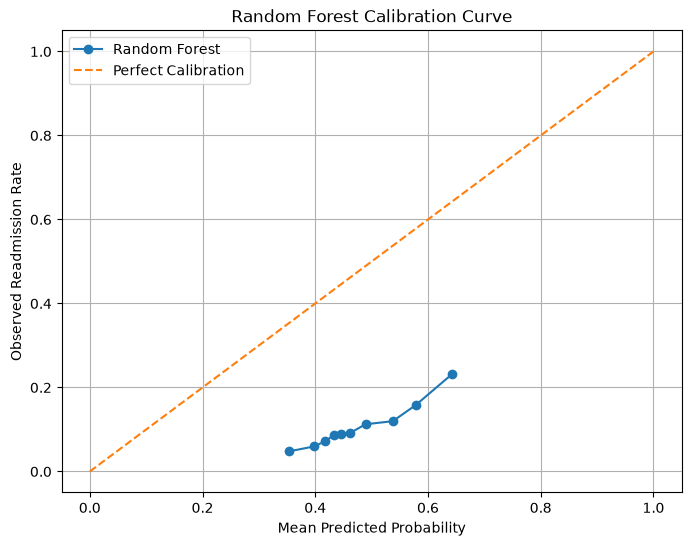

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate observed frequency vs predicted probability
prob_true, prob_pred = calibration_curve(
    y_test,
    rf_pred_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Random Forest Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    estimator=rf_model,
    method="sigmoid",
    cv=3
)

calibrated_rf.fit(
    X_train_rf,
    y_train
)

print("Calibrated Random Forest trained successfully.")

Calibrated Random Forest trained successfully.


In [ ]:
# Generate calibrated predictions
calibrated_rf_pred = calibrated_rf.predict(X_test_rf)

# Generate calibrated probabilities
calibrated_rf_pred_proba = calibrated_rf.predict_proba(X_test_rf)[:, 1]

print("First 10 calibrated predicted probabilities:")
print(calibrated_rf_pred_proba[:10])

First 10 calibrated predicted probabilities:
[0.08190325 0.07822332 0.1010049  0.0818029  0.07798053 0.07781593
 0.09977996 0.06926449 0.09605659 0.1713718 ]


In [ ]:
# Evaluate calibrated Random Forest

cal_accuracy = accuracy_score(y_test, calibrated_rf_pred)
cal_precision = precision_score(y_test, calibrated_rf_pred)
cal_recall = recall_score(y_test, calibrated_rf_pred)
cal_f1 = f1_score(y_test, calibrated_rf_pred)

cal_roc_auc = roc_auc_score(y_test, calibrated_rf_pred_proba)
cal_pr_auc = average_precision_score(y_test, calibrated_rf_pred_proba)

print(f"Accuracy:  {cal_accuracy:.4f}")
print(f"Precision: {cal_precision:.4f}")
print(f"Recall:    {cal_recall:.4f}")
print(f"F1 Score:  {cal_f1:.4f}")
print(f"ROC-AUC:   {cal_roc_auc:.4f}")
print(f"PR-AUC:    {cal_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, calibrated_rf_pred))

Accuracy:  0.8931
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.6439
PR-AUC:    0.2012

Confusion Matrix:
[[18120     0]
 [ 2169     0]]


c:\Users\Yohanes E\Desktop\healthcare-intelligence\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


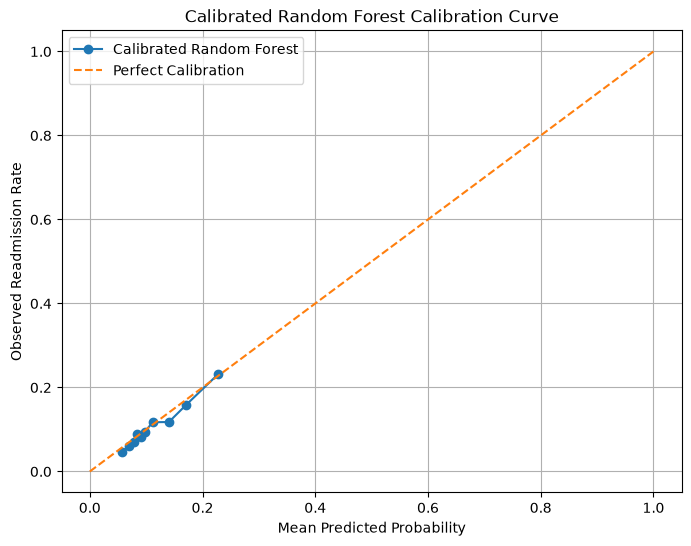

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate calibrated probabilities by bin
cal_prob_true, cal_prob_pred = calibration_curve(
    y_test,
    calibrated_rf_pred_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    cal_prob_pred,
    cal_prob_true,
    marker="o",
    label="Calibrated Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibrated Random Forest Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
calibrated_thresholds = [
    0.05,
    0.06,
    0.07,
    0.08,
    0.09,
    0.10,
    0.11,
    0.12,
    0.13,
    0.14,
    0.15,
    0.17,
    0.20,
    0.25
]

for threshold in calibrated_thresholds:
    threshold_pred = (
        calibrated_rf_pred_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.05 | Precision: 0.108 | Recall: 0.994 | F1: 0.195
Threshold: 0.06 | Precision: 0.111 | Recall: 0.979 | F1: 0.199
Threshold: 0.07 | Precision: 0.117 | Recall: 0.932 | F1: 0.208
Threshold: 0.08 | Precision: 0.126 | Recall: 0.845 | F1: 0.219
Threshold: 0.09 | Precision: 0.138 | Recall: 0.710 | F1: 0.231
Threshold: 0.10 | Precision: 0.154 | Recall: 0.602 | F1: 0.245
Threshold: 0.11 | Precision: 0.163 | Recall: 0.532 | F1: 0.250
Threshold: 0.12 | Precision: 0.167 | Recall: 0.496 | F1: 0.250
Threshold: 0.13 | Precision: 0.173 | Recall: 0.468 | F1: 0.252
Threshold: 0.14 | Precision: 0.181 | Recall: 0.428 | F1: 0.254
Threshold: 0.15 | Precision: 0.192 | Recall: 0.373 | F1: 0.253
Threshold: 0.17 | Precision: 0.212 | Recall: 0.296 | F1: 0.247
Threshold: 0.20 | Precision: 0.243 | Recall: 0.186 | F1: 0.211
Threshold: 0.25 | Precision: 0.405 | Recall: 0.077 | F1: 0.129


In [ ]:
selected_threshold = 0.14

selected_pred = (
    calibrated_rf_pred_proba >= selected_threshold
).astype(int)

print("Selected Threshold:", selected_threshold)
print("Accuracy:", accuracy_score(y_test, selected_pred))
print("Precision:", precision_score(y_test, selected_pred))
print("Recall:", recall_score(y_test, selected_pred))
print("F1:", f1_score(y_test, selected_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, selected_pred))

print("\nClassification Report:")
print(classification_report(y_test, selected_pred))

Selected Threshold: 0.14
Accuracy: 0.7312336734190941
Precision: 0.18066900038895373
Recall: 0.4283079760258183
F1: 0.2541376008753932

Confusion Matrix:
[[13907  4213]
 [ 1240   929]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84     18120
           1       0.18      0.43      0.25      2169

    accuracy                           0.73     20289
   macro avg       0.55      0.60      0.55     20289
weighted avg       0.84      0.73      0.77     20289



In [ ]:
feature_names = rf_preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of features: 187

First 20 features:
['numeric__age_numeric' 'numeric__number_outpatient'
 'numeric__number_emergency' 'numeric__number_inpatient'
 'numeric__total_prior_visits' 'numeric__prior_inpatient_visit'
 'numeric__diabetes_diagnosis' 'numeric__diagnosis_category_count'
 'categorical__gender_Female' 'categorical__gender_Male'
 'categorical__gender_Unknown' 'categorical__race_AfricanAmerican'
 'categorical__race_Asian' 'categorical__race_Caucasian'
 'categorical__race_Hispanic' 'categorical__race_Other'
 'categorical__race_Unknown' 'categorical__admission_type_Elective'
 'categorical__admission_type_Emergency'
 'categorical__admission_type_NULL']


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print(feature_importance.head(20))

                                             feature  importance
3                          numeric__number_inpatient    0.220181
5                     numeric__prior_inpatient_visit    0.167708
4                        numeric__total_prior_visits    0.164048
0                               numeric__age_numeric    0.043707
2                          numeric__number_emergency    0.042176
1                         numeric__number_outpatient    0.020459
120        categorical__medical_specialty_Cardiology    0.011466
115                  categorical__payer_code_Unknown    0.010852
59       categorical__diag_1_category_Symptoms/Signs    0.010668
98              categorical__diag_3_category_Unknown    0.009314
43          categorical__diag_1_category_Circulatory    0.009233
7                  numeric__diagnosis_category_count    0.008949
46   categorical__diag_1_category_Endocrine/Diabetes    0.007699
185           categorical__medical_specialty_Unknown    0.007343
27      categorical__admi

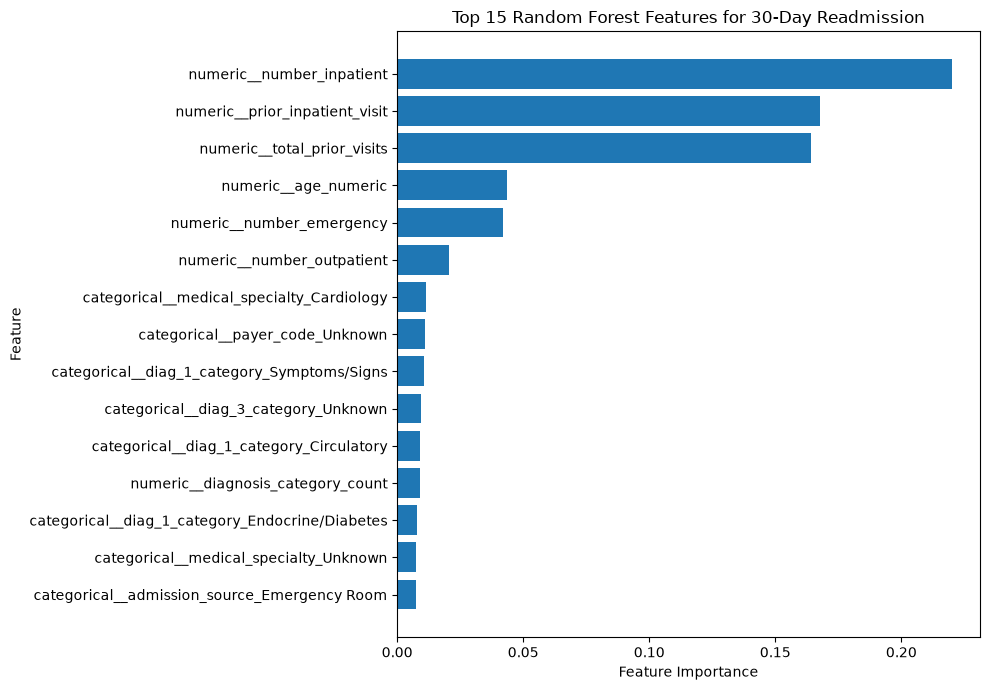

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features for 30-Day Readmission")

plt.tight_layout()
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [ ]:
import numpy as np

X_test_sample = X_test_rf[:2000].toarray().astype(float)

print("SHAP input shape:", X_test_sample.shape)
print("SHAP input dtype:", X_test_sample.dtype)

SHAP input shape: (2000, 187)
SHAP input dtype: float64


In [ ]:
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully.")
print("SHAP shape:", np.array(shap_values).shape)

SHAP values calculated successfully.
SHAP shape: (2000, 187, 2)


In [ ]:
shap_values_readmission = shap_values[:, :, 1]

print("Readmission SHAP shape:", shap_values_readmission.shape)

Readmission SHAP shape: (2000, 187)


In [ ]:
shap_values_readmission = shap_values[:, :, 1]

print("Readmission SHAP shape:", shap_values_readmission.shape)

Readmission SHAP shape: (2000, 187)


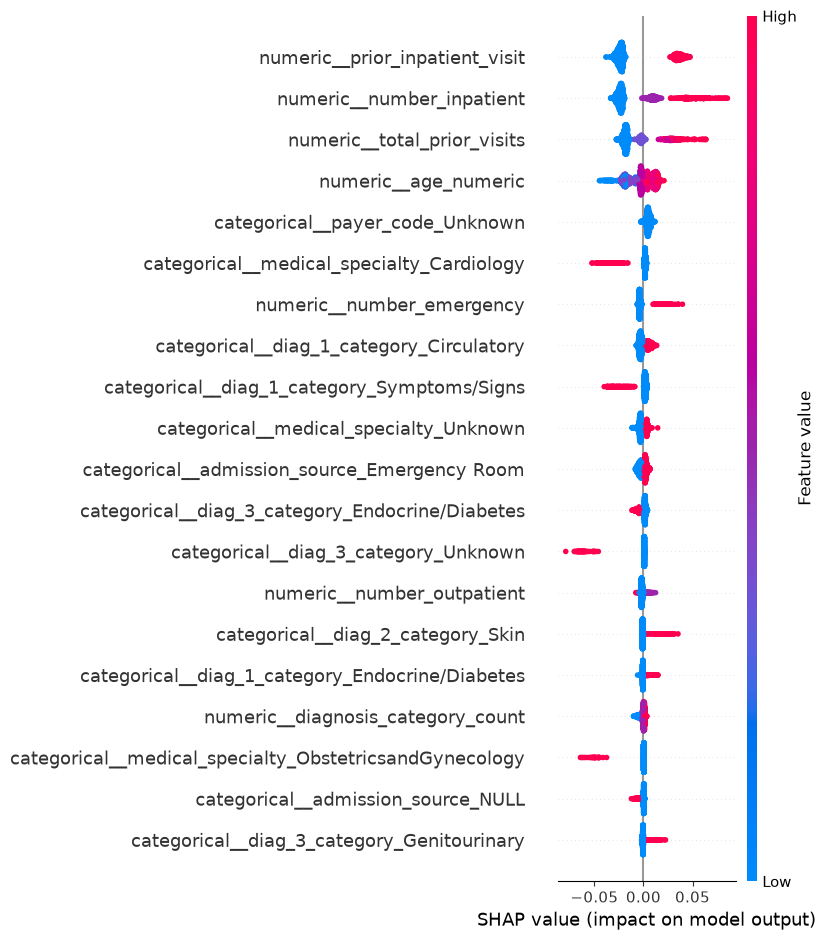

In [ ]:
shap.summary_plot(
    shap_values_readmission,
    X_test_sample,
    feature_names=feature_names,
    max_display=20
)

In [ ]:
# Get the original feature name for each transformed feature
group_names = []

for name in feature_names:
    name = name.split("__", 1)[-1]

    if "_" in name:
        original_feature = name.split("_", 1)[0]
    else:
        original_feature = name

    group_names.append(original_feature)

# Manually map transformed features back to their original variables
feature_groups = []

for name in feature_names:
    if name.startswith("numeric__age_numeric"):
        feature_groups.append("Age")
    elif name.startswith("numeric__number_outpatient"):
        feature_groups.append("Outpatient Utilization")
    elif name.startswith("numeric__number_emergency"):
        feature_groups.append("Emergency Utilization")
    elif name.startswith("numeric__number_inpatient"):
        feature_groups.append("Inpatient Utilization")
    elif name.startswith("numeric__total_prior_visits"):
        feature_groups.append("Total Prior Utilization")
    elif name.startswith("numeric__prior_inpatient_visit"):
        feature_groups.append("Prior Inpatient Visit")
    elif name.startswith("numeric__diabetes_diagnosis"):
        feature_groups.append("Diabetes Diagnosis")
    elif name.startswith("numeric__diagnosis_category_count"):
        feature_groups.append("Diagnosis Complexity")
    elif name.startswith("categorical__gender"):
        feature_groups.append("Gender")
    elif name.startswith("categorical__race"):
        feature_groups.append("Race")
    elif name.startswith("categorical__admission_type"):
        feature_groups.append("Admission Type")
    elif name.startswith("categorical__admission_source"):
        feature_groups.append("Admission Source")
    elif name.startswith("categorical__diag_1_category"):
        feature_groups.append("Primary Diagnosis")
    elif name.startswith("categorical__diag_2_category"):
        feature_groups.append("Secondary Diagnosis")
    elif name.startswith("categorical__diag_3_category"):
        feature_groups.append("Tertiary Diagnosis")
    elif name.startswith("categorical__payer_code"):
        feature_groups.append("Payer Code")
    elif name.startswith("categorical__medical_specialty"):
        feature_groups.append("Medical Specialty")
    else:
        feature_groups.append("Other")

# Calculate mean absolute SHAP value for each original feature
grouped_shap = pd.DataFrame({
    "feature_group": feature_groups,
    "mean_abs_shap": np.abs(shap_values_readmission).mean(axis=0)
})

grouped_shap = (
    grouped_shap
    .groupby("feature_group")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
)

print(grouped_shap)

feature_group
Prior Inpatient Visit      0.027423
Inpatient Utilization      0.024526
Total Prior Utilization    0.017731
Medical Specialty          0.013563
Primary Diagnosis          0.013108
Tertiary Diagnosis         0.010588
Age                        0.010099
Payer Code                 0.008134
Secondary Diagnosis        0.005570
Admission Source           0.004971
Emergency Utilization      0.004351
Admission Type             0.002655
Outpatient Utilization     0.001703
Race                       0.001501
Diagnosis Complexity       0.001162
Gender                     0.000782
Diabetes Diagnosis         0.000589
Name: mean_abs_shap, dtype: float64


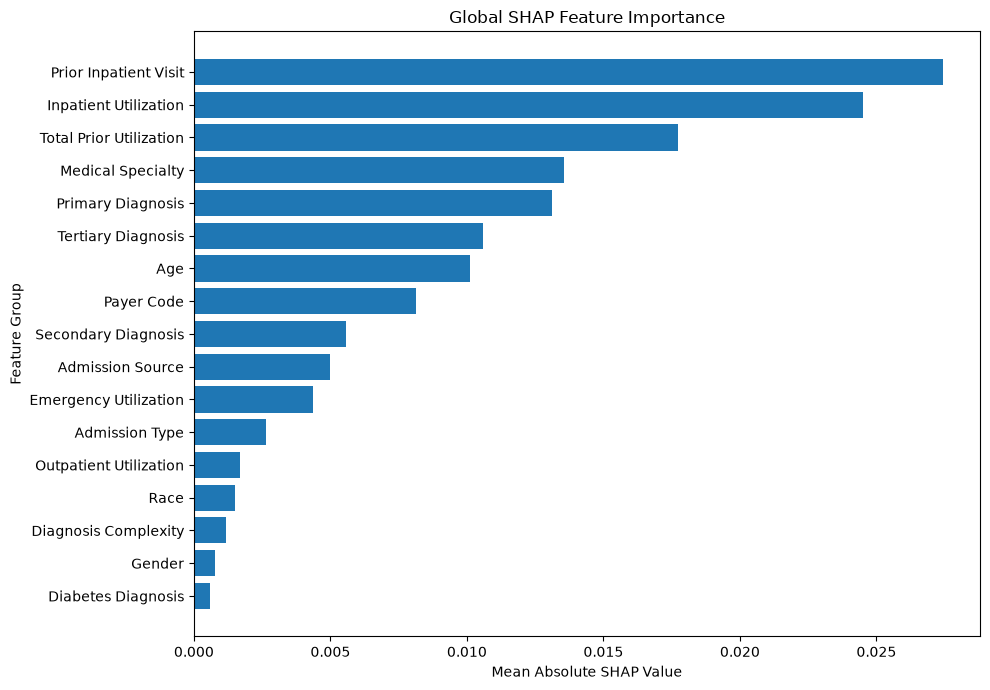

In [ ]:
top_grouped_shap = grouped_shap.sort_values(ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    top_grouped_shap.index,
    top_grouped_shap.values
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature Group")
plt.title("Global SHAP Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
risk_results = test_df[
    [
        "encounter_id",
        "patient_nbr",
        "age",
        "age_numeric",
        "gender",
        "race",
        "admission_type",
        "admission_source",
        "time_in_hospital",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "total_prior_visits",
        "prior_inpatient_visit",
        "diag_1_category",
        "diag_2_category",
        "diag_3_category",
        "medical_specialty",
        "payer_code",
        "readmitted_30"
    ]
].copy()

risk_results["predicted_readmission_risk"] = calibrated_rf_pred_proba

risk_results["risk_flag"] = (
    risk_results["predicted_readmission_risk"] >= selected_threshold
).astype(int)

risk_results["risk_category"] = pd.cut(
    risk_results["predicted_readmission_risk"],
    bins=[-float("inf"), 0.10, 0.14, 0.20, float("inf")],
    labels=[
        "Lower Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
)

print("Risk dataset shape:", risk_results.shape)
print("\nRisk categories:")
print(risk_results["risk_category"].value_counts())

Risk dataset shape: (20289, 23)

Risk categories:
risk_category
Lower Risk        11804
High Risk          3480
Moderate Risk      3343
Very High Risk     1662
Name: count, dtype: int64


In [ ]:
risk_results.to_csv(
    "../data/processed/readmission_risk_predictions.csv",
    index=False
)

print("Risk prediction dataset saved successfully.")
print(
    "Rows:",
    len(risk_results),
    "| Columns:",
    len(risk_results.columns)
)

Risk prediction dataset saved successfully.
Rows: 20289 | Columns: 23


In [ ]:
risk_validation = (
    risk_results
    .groupby("risk_category", observed=True)
    .agg(
        encounters=("readmitted_30", "size"),
        actual_readmissions=("readmitted_30", "sum"),
        actual_readmission_rate=("readmitted_30", "mean"),
        average_predicted_risk=("predicted_readmission_risk", "mean")
    )
    .reset_index()
)

risk_validation["actual_readmission_rate"] = (
    risk_validation["actual_readmission_rate"] * 100
)

risk_validation["average_predicted_risk"] = (
    risk_validation["average_predicted_risk"] * 100
)

print(risk_validation)

    risk_category  encounters  actual_readmissions  actual_readmission_rate  \
0      Lower Risk       11804                  864                 7.319553   
1   Moderate Risk        3343                  376                11.247383   
2       High Risk        3480                  525                15.086207   
3  Very High Risk        1662                  404                24.308063   

   average_predicted_risk  
0                7.872303  
1               11.649993  
2               16.541663  
3               23.507881  


In [ ]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest.joblib"
)

joblib.dump(
    calibrated_rf,
    "../models/calibrated_random_forest.joblib"
)

joblib.dump(
    rf_preprocessor,
    "../models/rf_preprocessor.joblib"
)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


In [ ]:
import json

model_metadata = {
    "model_type": "Random Forest Classifier",
    "calibrated_model": "Random Forest with sigmoid probability calibration",
    "target": "readmitted_30",
    "prediction_target": "30-day hospital readmission",
    "selected_threshold": 0.14,

    "features": admission_features,

    "train_patients": len(train_patients),
    "test_patients": len(test_patients),
    "train_encounters": len(train_df),
    "test_encounters": len(test_df),

    "evaluation": {
        "accuracy": 0.7312336734190941,
        "precision": 0.18066900038895373,
        "recall": 0.4283079760258183,
        "f1": 0.2541376008753932,
        "roc_auc": 0.6439,
        "pr_auc": 0.2012
    },

    "calibration": {
        "method": "sigmoid",
        "calibration_model": "CalibratedClassifierCV"
    },

    "threshold_selection": {
        "criterion": "highest F1 among evaluated thresholds",
        "threshold": 0.14
    }
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Model metadata saved successfully.")

Model metadata saved successfully.


In [ ]:
import pandas as pd

df_sql = pd.read_csv("../data/processed/diabetic_engineered.csv")

print(df_sql.shape)
print(df_sql.columns.tolist())

(101766, 67)
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmitted_30', 'admission_type', 'admission_source', 'discharge_disposition', 'age_numeric', 'total_prior_visits', 'prior_inpatient_visit', 'medication_count', 'medication_chang

In [ ]:
sql_columns = [
    "encounter_id",
    "patient_nbr",
    "age",
    "age_numeric",
    "gender",
    "race",
    "admission_type_id",
    "admission_type",
    "admission_source_id",
    "admission_source",
    "discharge_disposition_id",
    "discharge_disposition",
    "time_in_hospital",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "total_prior_visits",
    "prior_inpatient_visit",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses",
    "medication_count",
    "medication_changed",
    "diabetes_medication",
    "diabetes_diagnosis",
    "diagnosis_category_count",
    "diag_1_category",
    "diag_2_category",
    "diag_3_category",
    "high_medication_burden",
    "long_stay",
    "payer_code",
    "medical_specialty",
    "readmitted",
    "readmitted_30"
]

df_sql = df_sql[sql_columns]

print(df_sql.shape)

(101766, 36)


In [ ]:
missing_columns = [
    col for col in sql_columns
    if col not in df_sql.columns
]

print(missing_columns)

[]


In [ ]:
import os

from sqlalchemy import create_engine

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv(
    "DB_NAME",
    "healthcare_intelligence"
)
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD")

if not DB_PASSWORD:
    raise ValueError(
        "DB_PASSWORD environment variable is not set."
    )

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [2]:
import os

from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "healthcare_intelligence")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD")

if not DB_PASSWORD:
    raise ValueError(
        "DB_PASSWORD environment variable is not set."
    )

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [ ]:
df_sql.to_sql(
    "encounters",
    engine,
    schema="public",
    if_exists="append",
    index=False,
    chunksize=5000,
    method="multi"
)

101766

In [ ]:
risk_results.columns.tolist()

['encounter_id',
 'patient_nbr',
 'age',
 'age_numeric',
 'gender',
 'race',
 'admission_type',
 'admission_source',
 'time_in_hospital',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'total_prior_visits',
 'prior_inpatient_visit',
 'diag_1_category',
 'diag_2_category',
 'diag_3_category',
 'medical_specialty',
 'payer_code',
 'readmitted_30',
 'predicted_readmission_risk',
 'risk_flag',
 'risk_category']

In [ ]:
risk_results.shape

(20289, 23)

In [ ]:
risk_results[
    [
        "encounter_id",
        "predicted_readmission_risk",
        "risk_flag",
        "risk_category",
        "readmitted_30"
    ]
].head()

,encounter_id,predicted_readmission_risk,risk_flag,risk_category,readmitted_30
4,16680,0.081903,0,Lower Risk,0
6,55842,0.078223,0,Lower Risk,0
32,260166,0.101005,0,Moderate Risk,0
35,325848,0.081803,0,Lower Risk,0
39,377268,0.077981,0,Lower Risk,0


In [ ]:
prediction_columns = [
    "encounter_id",
    "predicted_readmission_risk",
    "risk_flag",
    "risk_category",
    "readmitted_30"
]

df_predictions = risk_results[prediction_columns].copy()

print(df_predictions.shape)

(20289, 5)


In [ ]:
print(df_predictions.columns.tolist())

['encounter_id', 'predicted_readmission_risk', 'risk_flag', 'risk_category', 'readmitted_30']


In [ ]:
df_predictions = risk_results[
    [
        "encounter_id",
        "predicted_readmission_risk",
        "risk_flag",
        "risk_category",
        "readmitted_30"
    ]
].copy()

df_predictions = df_predictions.rename(
    columns={"readmitted_30": "actual_readmitted_30"}
)

print(df_predictions.columns.tolist())

['encounter_id', 'predicted_readmission_risk', 'risk_flag', 'risk_category', 'actual_readmitted_30']


In [ ]:
df_predictions.to_sql(
    "readmission_predictions",
    engine,
    schema="public",
    if_exists="append",
    index=False,
    chunksize=5000,
    method="multi"
)

20289